# Pipeline Preditivo para Análise de Risco de Crédito

**Projeto avaliativo — Machine Learning e Visão Computacional — SCTEC/SENAI**
Autor: Francesco Cousseau

**Objetivo de negócio:** prever `loan_status` (1 = inadimplente) para uma instituição financeira, comparando **KNN** e **Árvore de Decisão** sob três lentes: generalização, análise de erros (FP × FN) e **impacto financeiro em reais**.

---

### Duas decisões de arquitetura que governam todo o notebook

**1. A lógica vive em `src/`, não aqui.** Transformadores, pipelines e o modelo de custo estão nos módulos do projeto. Este notebook é a **narrativa analítica** — ele importa, executa e interpreta. Assim não existe código duplicado entre o notebook e a biblioteca, e o que é testado é o que roda.

**2. Todo o pré-processamento vive dentro de um `Pipeline`.** Imputação, escalonamento e balanceamento são ajustados **apenas no fold de treino**, nunca no de validação. Isso torna o vazamento de dados *estruturalmente impossível*, em vez de depender da disciplina de quem escreve as células. O conjunto de teste é aberto **uma única vez**, na Fase 6.

## 1. Importações e configuração

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

# ---- Módulos do projeto: fonte única da verdade ----
sys.path.append(str(Path.cwd().parent))

from src import config as cfg
from src.data_quality import (
    build_quality_report, clean_basic_data, load_data, validate_business_rules,
)
from src.preprocessing import add_income_commitment, build_pipeline, drop_redundant_feature
from src.modeling import make_cv, prove_scale_invariance, run_grid, select_best
from src.evaluation import BusinessCost, plot_confusion_matrices

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = cfg.RANDOM_STATE
TARGET = cfg.TARGET
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "credit_risk_dataset.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
RESULTS_DIR = PROJECT_ROOT / "reports" / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df = load_data(DATA_PATH)
print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
display(df.head())

Linhas: 32,581 | Colunas: 12


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Fase 1 — Análise Exploratória de Dados (EDA)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [4]:
print("=== Sumário estatístico — variáveis numéricas ===")
display(df.describe().T)
print("=== Sumário estatístico — variáveis categóricas ===")
display(df.describe(include="object").T)

=== Sumário estatístico — variáveis numéricas ===


,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


=== Sumário estatístico — variáveis categóricas ===


/tmp/ipykernel_584/176019093.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836


In [5]:
display(build_quality_report(df))

,tipo,nulos,%_nulos,valores_unicos
loan_int_rate,float64,3116,9.56,349
person_emp_length,float64,895,2.75,37
person_income,int64,0,0.00,4295
person_age,int64,0,0.00,58
person_home_ownership,str,0,0.00,4
loan_intent,str,0,0.00,6
loan_grade,str,0,0.00,7
loan_amnt,int64,0,0.00,753
loan_status,int64,0,0.00,2
loan_percent_income,float64,0,0.00,77


### 2.1 Auditoria de regras de negócio

Antes de olhar gráficos, testo hipóteses lógicas. Um outlier estatístico pode ser um cliente legítimo; um **erro de cadastro** não é outlier, é dado sujo — e a distinção muda completamente o tratamento.

In [6]:
display(validate_business_rules(df))

print("Idades máximas observadas:", sorted(df.person_age.unique())[-6:])
print("Tempos de emprego máximos:", sorted(df.person_emp_length.dropna().unique())[-6:])

,registros
idade fora de 18-100 anos,5
tempo de emprego > (idade - 14),2
renda <= 0,0
empréstimo <= 0,0
duplicatas completas,165


Idades máximas observadas: [np.int64(78), np.int64(80), np.int64(84), np.int64(94), np.int64(123), np.int64(144)]
Tempos de emprego máximos: [np.float64(30.0), np.float64(31.0), np.float64(34.0), np.float64(38.0), np.float64(41.0), np.float64(123.0)]


Há registros com **144 anos de idade** e **123 anos de tempo de emprego**. Não são caudas de distribuição: são erros de digitação. Serão tratados na Fase 2 como problema de **qualidade**, não de **outlier estatístico**.

### 2.2 Gráfico 1 — desbalanceamento da variável alvo

,quantidade,percentual
loan_status,,
0,25473,78.18
1,7108,21.82


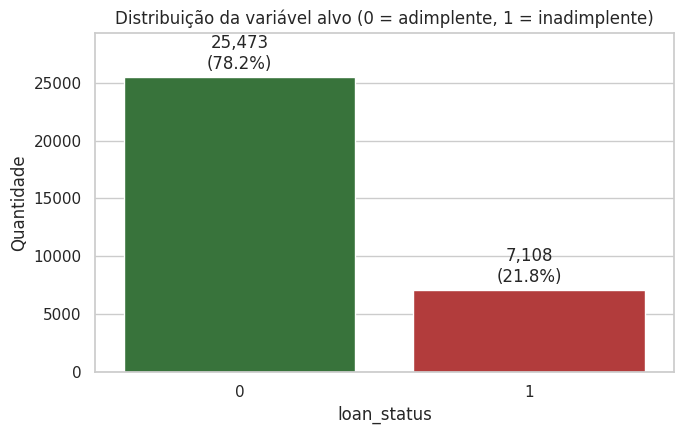

In [7]:
display(pd.DataFrame({
    "quantidade": df[TARGET].value_counts().sort_index(),
    "percentual": (df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2),
}))

plt.figure(figsize=(7, 4.5))
ax = sns.countplot(data=df, x=TARGET, hue=TARGET, palette=["#2E7D32", "#C62828"], legend=False)
for c in ax.containers:
    ax.bar_label(c, labels=[f"{int(b.get_height()):,}\n({b.get_height()/len(df):.1%})" for b in c], padding=3)
plt.title("Distribuição da variável alvo (0 = adimplente, 1 = inadimplente)")
plt.xlabel("loan_status"); plt.ylabel("Quantidade"); plt.ylim(0, len(df) * 0.9)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "01_distribuicao_target.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.3 Gráfico 2 — distribuição da renda anual

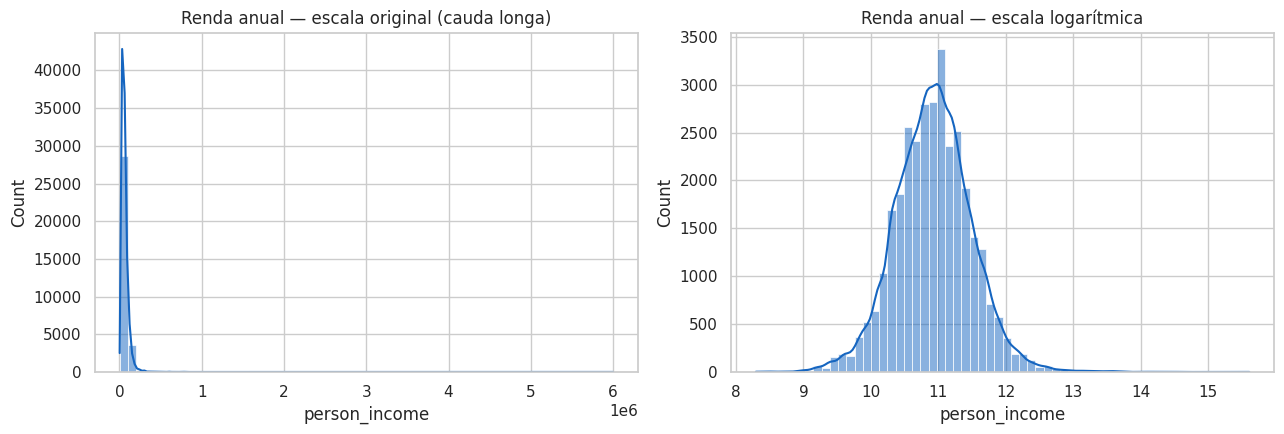

Assimetria (skewness) da renda: 32.87
Média: 66,075 | Mediana: 55,000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df.person_income, bins=60, kde=True, ax=axes[0], color="#1565C0")
axes[0].set_title("Renda anual — escala original (cauda longa)")
sns.histplot(np.log1p(df.person_income), bins=60, kde=True, ax=axes[1], color="#1565C0")
axes[1].set_title("Renda anual — escala logarítmica")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "02_distribuicao_renda.png", dpi=300, bbox_inches="tight")
plt.show()

print("Assimetria (skewness) da renda:", round(df.person_income.skew(), 2))
print("Média: {:,.0f} | Mediana: {:,.0f}".format(df.person_income.mean(), df.person_income.median()))

A renda é **fortemente assimétrica à direita** — a média fica bem acima da mediana. Esse é o argumento estatístico que justifica usar a **mediana** (e não a média) em toda imputação numérica: a média seria arrastada pela cauda dos altos rendimentos e distorceria os valores imputados.

### 2.4 Gráfico 3 — correlação de Pearson

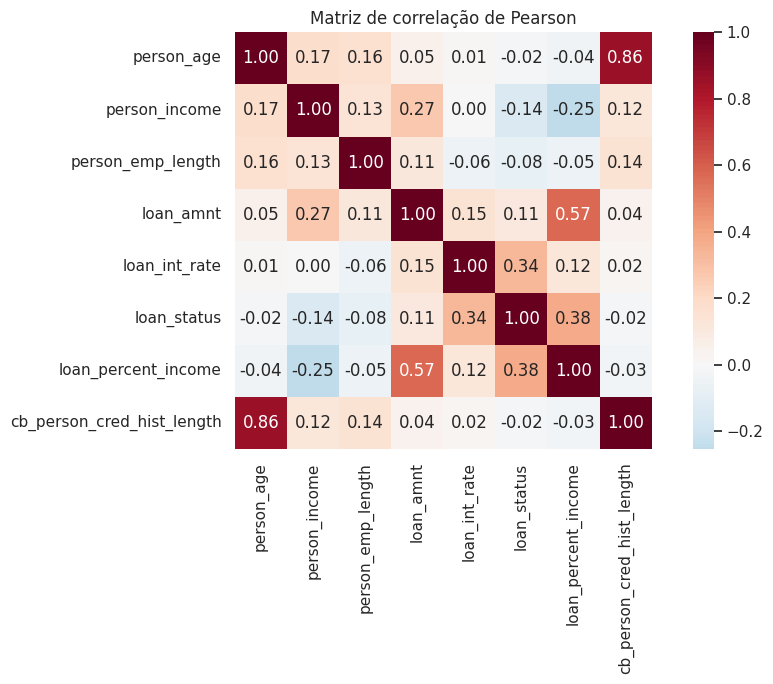

In [9]:
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", center=0, cmap="RdBu_r", square=True)
plt.title("Matriz de correlação de Pearson")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "03_correlacao_pearson.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.5 Gráfico 4 — boxplots e diagnóstico de outliers

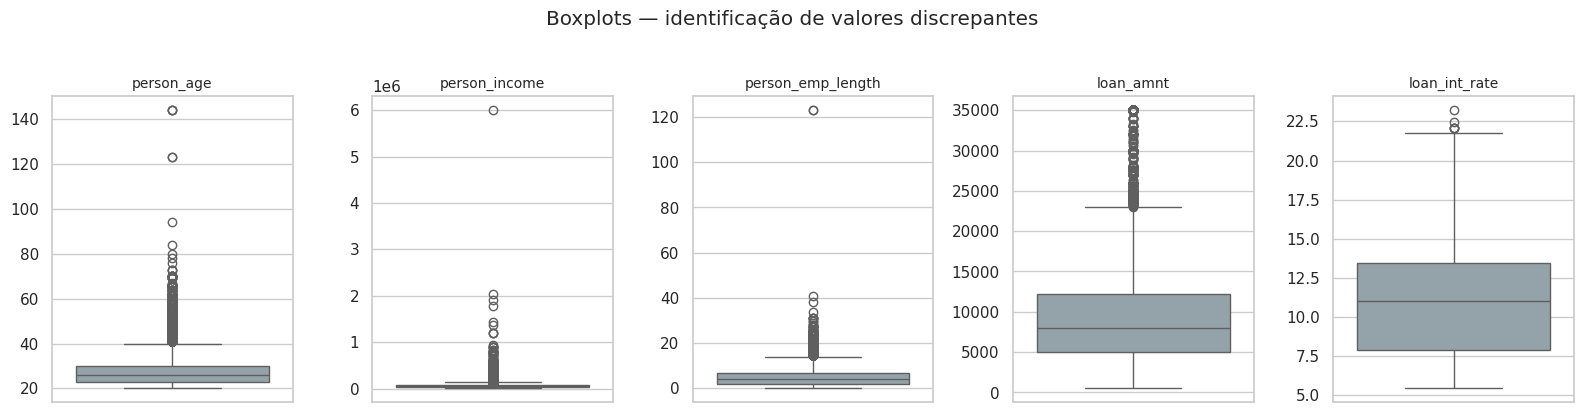

,variavel,outliers_IQR,%_da_base
0,person_age,1494,4.59
1,person_income,1484,4.55
2,person_emp_length,853,2.62
3,loan_amnt,1689,5.18
4,loan_int_rate,6,0.02


In [10]:
cols_box = ["person_age", "person_income", "person_emp_length", "loan_amnt", "loan_int_rate"]

fig, axes = plt.subplots(1, len(cols_box), figsize=(16, 4))
for ax, c in zip(axes, cols_box):
    sns.boxplot(y=df[c], ax=ax, color="#90A4AE")
    ax.set_title(c, fontsize=10); ax.set_ylabel("")
plt.suptitle("Boxplots — identificação de valores discrepantes", y=1.03)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "04_boxplots_outliers.png", dpi=300, bbox_inches="tight")
plt.show()

iqr = []
for c in cols_box:
    q1, q3 = df[c].quantile([0.25, 0.75]); amp = q3 - q1
    fora = ((df[c] < q1 - 1.5 * amp) | (df[c] > q3 + 1.5 * amp)).sum()
    iqr.append({"variavel": c, "outliers_IQR": fora, "%_da_base": round(fora / len(df) * 100, 2)})
display(pd.DataFrame(iqr))

### 2.6 Gráfico 5 — relação das variáveis-chave com o alvo

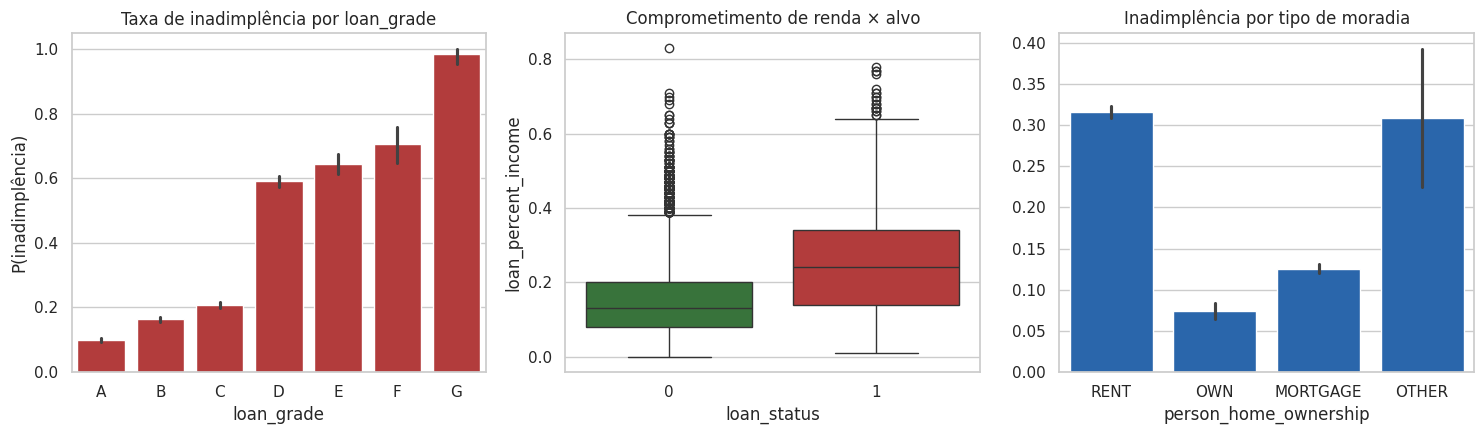

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.barplot(data=df, x="loan_grade", y=TARGET, order=list("ABCDEFG"), ax=axes[0], color="#C62828")
axes[0].set_title("Taxa de inadimplência por loan_grade"); axes[0].set_ylabel("P(inadimplência)")
sns.boxplot(data=df, x=TARGET, y="loan_percent_income", hue=TARGET,
            palette=["#2E7D32", "#C62828"], legend=False, ax=axes[1])
axes[1].set_title("Comprometimento de renda × alvo")
sns.barplot(data=df, x="person_home_ownership", y=TARGET, ax=axes[2], color="#1565C0")
axes[2].set_title("Inadimplência por tipo de moradia"); axes[2].set_ylabel("")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "05_relacoes_alvo.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.7 Parágrafo analítico — o que a EDA revelou e como ela guia a preparação

A base tem **32.581 linhas e 12 colunas**, com **165 duplicatas completas** e desbalanceamento relevante: **78,2% adimplentes contra 21,8% inadimplentes**. Isso já condena a acurácia como métrica de decisão — um modelo que aprovasse todo mundo acertaria 78% e seria comercialmente inútil, pois não bloquearia um único calote. Por isso a seleção será feita pelo **F1 e pelo recall da classe 1**, e o veredito final será dado em **reais**, não em percentuais.

Três achados dirigem a estratégia de preparação. Primeiro, **`loan_int_rate` tem 9,6% de ausência e `person_emp_length` 2,7%**; como a renda e o valor do empréstimo são fortemente assimétricos à direita, a **mediana** é o imputador correto — a média seria arrastada pela cauda. Além disso, a taxa de juros é quase uma função determinística do `loan_grade`, então imputá-la pela **mediana dentro de cada grade** preserva muito mais informação do que uma mediana global. Segundo, os boxplots mostram caudas longas em renda e valor do empréstimo, mas é preciso separar **outlier legítimo** (um cliente que ganha muito de fato) de **erro de cadastro** (144 anos de idade, 123 anos de emprego): os primeiros serão preservados, os segundos corrigidos. Como o KNN mede distâncias euclidianas, uma renda extrema domina o cálculo e distorce a vizinhança; já a árvore faz cortes ordinais e é indiferente a isso. Logo, o tratamento de outliers será **assimétrico entre os dois modelos**.

Terceiro, o mapa de correlação e os gráficos por alvo mostram que **`loan_grade`, o comprometimento de renda e o tipo de moradia** são os sinais mais fortes de inadimplência: a taxa de calote sobe monotonicamente de A para G, e quem aluga inadimple muito mais que quem tem imóvel quitado. Isso valida a feature obrigatória como economicamente sensata e sugere tratar `loan_grade` como variável **ordinal**, não nominal — one-hot destruiria a ordem A < B < ... < G, que é exatamente o que carrega o sinal.

## 3. Fase 2 — Tratamento e Limpeza

A rotina `clean_basic_data` (em `src/data_quality.py`) aplica quatro decisões, nesta ordem:

1. **Duplicatas saem ANTES do split.** Motivo é vazamento, não estética: se uma linha e sua cópia idêntica caíssem em lados opostos do split, o modelo teria **visto o gabarito da prova durante o estudo**.
2. **Idade fora de 18–100 anos → remove a linha** (o cadastro inteiro é suspeito).
3. **`emp_length > idade − 14` → anula o campo**, não a linha. A linha é aproveitável; só o campo corrompido vira `NaN`, imputado depois **dentro do pipeline**, com estatística de treino.
4. **Renda ou empréstimo ≤ 0 → remove** (inviabilizam a feature de comprometimento).

In [12]:
df_clean = clean_basic_data(df)

Duplicatas removidas: 165
Idades impossíveis removidas: 5
Tempos de emprego convertidos em NaN: 2
Renda/empréstimo não positivos removidos: 0
32,581 -> 32,411 linhas (retenção: 99.48%)


### 3.1 Decisão sobre outliers: manter na árvore, clipping no KNN

Decisão **fundamentada e assimétrica** — não uma remoção cega por IQR:

| | Árvore de Decisão | KNN |
|---|---|---|
| Como usa o valor | corte ordinal (`renda > X?`) | **distância euclidiana** |
| Efeito de um outlier | nenhum — a ordem não muda | **domina a métrica de distância** |
| **Decisão** | **manter** os valores íntegros | **clipping no percentil 99** |

Remover as ~4.000 linhas apontadas pelo IQR jogaria fora clientes de alta renda perfeitamente legítimos — e clientes de alta renda são justamente os bons pagadores que o banco não quer perder. O clipping preserva a **linha** e apenas achata o **valor extremo**, e é aplicado só onde causa dano. Os percentis são calculados **dentro do pipeline** (`Winsorizer`), portanto ajustados apenas no treino. A decisão é validada empiricamente na seção 5.5.

## 4. Fase 3 — Feature Engineering

`comprometimento_renda = (loan_amnt / person_income) * 100` — o percentual da renda anual comprometido com o empréstimo. É a razão dívida/renda, o indicador mais clássico de capacidade de pagamento. A divisão por zero está estruturalmente impedida: a Fase 2 já garantiu `person_income > 0`.

In [13]:
df_clean = add_income_commitment(df_clean)

print("Nulos gerados:", df_clean.comprometimento_renda.isna().sum())
print("Infinitos gerados:", np.isinf(df_clean.comprometimento_renda).sum())
display(df_clean.comprometimento_renda.describe().round(2))

Nulos gerados: 0
Infinitos gerados: 0


count    32411.00
mean        17.06
std         10.71
min          0.08
25%          8.97
50%         14.81
75%         22.92
max         83.00
Name: comprometimento_renda, dtype: float64

### 4.1 Teste de redundância com `loan_percent_income`

Correlação de Pearson: 0.9989


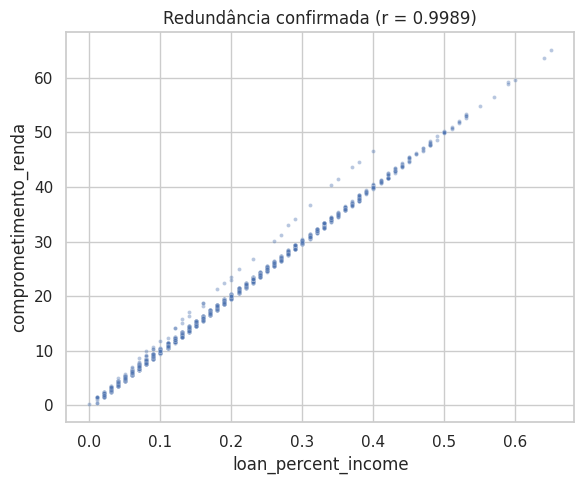

In [14]:
corr_red = df_clean[["loan_percent_income", "comprometimento_renda"]].corr().iloc[0, 1]
print(f"Correlação de Pearson: {corr_red:.4f}")

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_clean.sample(3000, random_state=RANDOM_STATE),
                x="loan_percent_income", y="comprometimento_renda", s=8, alpha=0.4)
plt.title(f"Redundância confirmada (r = {corr_red:.4f})")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "06_redundancia.png", dpi=300, bbox_inches="tight")
plt.show()

**Decisão:** com **r = 0,9989**, as duas colunas são a mesma informação em escalas diferentes. Manter ambas **duplicaria o peso dessa dimensão no cálculo de distância do KNN**, dando a ela o dobro da influência de qualquer outra variável — um viés silencioso. `loan_percent_income` fica na EDA e sai da matriz de modelagem.

In [15]:
model_df = drop_redundant_feature(df_clean)
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]
print("Preditoras:", X.shape[1], "| Registros:", X.shape[0])

Preditoras: 11 | Registros: 32411


## 5. Fase 4 — Split, Balanceamento e Escalonamento Seguro

### 5.1 Split estratificado (80/20)

O `stratify=y` garante que treino e teste preservem a proporção 78/22 — sem ele, o sorteio poderia entregar um teste com prevalência diferente e tornar a métrica incomparável.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}")
display(pd.DataFrame({
    "treino_%": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "teste_%": (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
}))

Treino: 25,928 | Teste: 6,483


,treino_%,teste_%
loan_status,,
0,78.13,78.13
1,21.87,21.87


### 5.2 Encoding: cada tipo de variável com a técnica certa

Definido em `src/preprocessing.build_preprocessor`:

- **`loan_grade` → `OrdinalEncoder`** com a ordem A < B < ... < G explicitada. One-hot destruiria a ordem que carrega o sinal de risco e ainda somaria 7 dimensões — veneno para o KNN (maldição da dimensionalidade).
- **`cb_person_default_on_file` (Y/N) → binária** (0/1). Uma coluna, não duas.
- **`person_home_ownership`, `loan_intent` → `OneHotEncoder`**, pois são genuinamente nominais (não existe "aluguel < hipoteca").
- **Numéricas → mediana**, pelo argumento da assimetria; e **`loan_int_rate` → mediana por `loan_grade`** (`RateByGradeImputer`).

In [17]:
print(cfg.NUMERICAS, "-> mediana" + (" + StandardScaler (só KNN)"))
print(cfg.NOMINAIS, "-> OneHotEncoder")
print(cfg.ORDINAL, "-> OrdinalEncoder", cfg.GRADES)
print(cfg.BINARIA, "-> binária", cfg.BINARIA_CATEGORIAS)
print(cfg.WINSORIZAR, "-> clipping p99 (só KNN)")

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length', 'comprometimento_renda'] -> mediana + StandardScaler (só KNN)
['person_home_ownership', 'loan_intent'] -> OneHotEncoder
['loan_grade'] -> OrdinalEncoder ['A', 'B', 'C', 'D', 'E', 'F', 'G']
['cb_person_default_on_file'] -> binária ['N', 'Y']
['person_income', 'person_emp_length', 'loan_amnt', 'comprometimento_renda'] -> clipping p99 (só KNN)


### 5.3 Balanceamento: por que **RandomUnderSampler** e não SMOTE

O enunciado permite SMOTE **ou** Random Under Sampling. Testei os dois — e o SMOTE tem dois defeitos graves **neste** pipeline:

1. **Ele quebra o one-hot.** O SMOTE interpola linearmente entre vizinhos. Aplicado sobre a matriz codificada, produz linhas com `home_ownership_MORTGAGE = 0.71` e `home_ownership_RENT = 0.29` — um cliente que é 71% dono e 29% inquilino. Isso não existe no mundo real, e o modelo aprende cortes que nunca se repetirão no teste.
2. **Ele é sensível à escala.** O SMOTE busca vizinhos por distância euclidiana. Na árvore, cujos dados não são escalonados, `person_income` domina totalmente a busca — os dados sintéticos viram interpolações quase só de renda. Pior: isso **destruiria a prova de invariância de escala** da árvore, porque escalonar mudaria os dados sintéticos e, portanto, a árvore.

O `RandomUnderSampler` não sintetiza nada, não calcula distância e não tem escala. Abaixo, a comparação empírica que fundamenta a escolha — **e a demonstração numérica do one-hot quebrado**.

In [18]:
# --- Prova: o SMOTE fabrica clientes que não existem ---
from imblearn.under_sampling import RandomUnderSampler
from src.preprocessing import build_preprocessor, RateByGradeImputer

prep = build_preprocessor(escalonar=False)
X_enc = prep.fit_transform(RateByGradeImputer().fit(X_train).transform(X_train))
X_smote, _ = SMOTE(random_state=RANDOM_STATE).fit_resample(X_enc, y_train)

n_num = len(cfg.NUMERICAS)
n_ohe = X_enc.shape[1] - n_num - 2          # colunas one-hot (nominais)
bloco_ohe = X_smote[:, n_num:n_num + n_ohe]
fracionarias = ((bloco_ohe > 1e-6) & (bloco_ohe < 1 - 1e-6)).any(axis=1).sum()

print(f"Linhas com one-hot FRACIONÁRIO após SMOTE: {fracionarias:,} de {len(X_smote):,} "
      f"({fracionarias/len(X_smote):.1%})")
print("Exemplo de linha sintética (colunas one-hot):", np.round(bloco_ohe[-1], 3))

Linhas com one-hot FRACIONÁRIO após SMOTE: 12,685 de 40,514 (31.3%)
Exemplo de linha sintética (colunas one-hot): [0.71 0.   0.   0.29 0.   0.   0.   1.   0.   0.  ]


In [19]:
# --- Experimento: qual balanceador usar? (árvore, max_depth=7) ---
cv = make_cv()
arvore = lambda cw=None: DecisionTreeClassifier(max_depth=7, class_weight=cw, random_state=RANDOM_STATE)

candidatos = {
    "sem balanceamento": build_pipeline(arvore(), False, False, balancear=False),
    "RandomUnderSampler": build_pipeline(arvore(), False, False),
    "class_weight=balanced": build_pipeline(arvore("balanced"), False, False, balancear=False),
    "SMOTE": build_pipeline(arvore(), False, False, balanceador=SMOTE(random_state=RANDOM_STATE)),
}

experimentos = [
    {
        "estrategia": nome,
        "f1_cv": cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1").mean(),
        "recall_cv": cross_val_score(pipe, X_train, y_train, cv=cv, scoring="recall").mean(),
    }
    for nome, pipe in candidatos.items()
]

display(pd.DataFrame(experimentos).round(4).sort_values("recall_cv", ascending=False))

,estrategia,f1_cv,recall_cv
1,RandomUnderSampler,0.7908,0.7307
2,class_weight=balanced,0.7949,0.7307
0,sem balanceamento,0.8167,0.7011
3,SMOTE,0.8003,0.6893


**Leitura do experimento:** o `RandomUnderSampler` entrega o **melhor recall da classe inadimplente** entre as técnicas de reamostragem (≈ 0,73 contra ≈ 0,69 do SMOTE). Como o custo do negócio está concentrado no falso negativo, **recall é a métrica que paga a conta** — e o RUS ainda tem a vantagem de não fabricar clientes sintéticos impossíveis. É a escolha final para ambos os modelos.

### 5.4 Prova: a árvore dispensa escalonamento

Não basta afirmar. `prove_scale_invariance` treina a **mesma árvore** duas vezes — uma com `StandardScaler`, outra sem — e compara as predições no teste.

In [20]:
concordancia = prove_scale_invariance(X_train, y_train, X_test, max_depth=5)
print(f"Concordância entre a árvore COM e SEM escalonamento: {concordancia:.2%}")
assert concordancia == 1.0, "Deveriam ser idênticas!"

print()
print("Predições 100% idênticas. A árvore particiona por cortes ordinais ('renda > X?').")
print("O StandardScaler é uma transformação monotônica — ele reordena os valores? Não.")
print("Logo, os mesmos cortes são encontrados: escalonar é trabalho inútil na árvore.")
print()
print("Já o KNN mede distância euclidiana: sem escala, person_income (~10^4) esmagaria")
print("person_age (~10^1), e a vizinhança seria decidida praticamente só pela renda.")

Concordância entre a árvore COM e SEM escalonamento: 100.00%

Predições 100% idênticas. A árvore particiona por cortes ordinais ('renda > X?').
O StandardScaler é uma transformação monotônica — ele reordena os valores? Não.
Logo, os mesmos cortes são encontrados: escalonar é trabalho inútil na árvore.

Já o KNN mede distância euclidiana: sem escala, person_income (~10^4) esmagaria
person_age (~10^1), e a vizinhança seria decidida praticamente só pela renda.


### 5.5 Impacto do clipping — confirmando a decisão assimétrica sobre outliers

In [21]:
impacto = []
for nome, modelo, escalonar in [
    ("KNN (k=9)", KNeighborsClassifier(n_neighbors=9), True),
    ("Árvore (depth=7)", DecisionTreeClassifier(max_depth=7, random_state=RANDOM_STATE), False),
]:
    for clip in [False, True]:
        f1 = cross_val_score(build_pipeline(modelo, escalonar, clip),
                             X_train, y_train, cv=cv, scoring="f1").mean()
        impacto.append({"modelo": nome, "clipping_p99": clip, "f1_cv": round(f1, 4)})

display(pd.DataFrame(impacto))

,modelo,clipping_p99,f1_cv
0,KNN (k=9),False,0.6582
1,KNN (k=9),True,0.6616
2,Árvore (depth=7),False,0.7908
3,Árvore (depth=7),True,0.7914


O clipping **melhora o KNN** e é praticamente **indiferente para a árvore** — exatamente o que a teoria previa. Decisão confirmada: winsorização apenas no ramo do KNN.

## 6. Fase 5 — Modelagem, Otimização e Diagnóstico de Overfitting

### Duas correções metodológicas (codificadas em `src/modeling.py`)

**(a) O hiperparâmetro é escolhido por validação cruzada no treino, nunca olhando o teste.** Escolher `k` ou `max_depth` pela performance no teste é *selection leakage*: o holdout deixa de ser honesto e vira conjunto de validação disfarçado. Uso `StratifiedKFold` de 5 folds **dentro do treino**; o teste só será tocado na Fase 6.

**(b) A métrica de treino é medida no treino REAL, não no balanceado.** Comparar o F1 do treino balanceado (50% de positivos) com o F1 do teste (22% de positivos) é comparar laranjas com maçãs: o F1 depende da prevalência, então boa parte do "gap" seria puro artefato de proporção — e não overfitting.

In [22]:
tabela = run_grid(X_train, y_train, ks=[3, 5, 7, 9], depths=[3, 5, 7, None], cv=cv)
display(tabela.round(4))
tabela.to_csv(RESULTS_DIR / "grid_hiperparametros.csv", index=False)

,modelo,parametro,valor,f1_train,f1_cv,recall_cv,gap
0,KNN,k=3,3.0,0.7125,0.6301,0.7734,0.0824
1,KNN,k=5,5.0,0.7064,0.6415,0.7729,0.0649
2,KNN,k=7,7.0,0.6986,0.6542,0.7768,0.0443
3,KNN,k=9,9.0,0.6922,0.6616,0.7799,0.0305
4,Árvore,max_depth=3,3.0,0.7236,0.7257,0.7374,-0.0021
5,Árvore,max_depth=5,5.0,0.7912,0.7704,0.7389,0.0208
6,Árvore,max_depth=7,7.0,0.7920,0.7908,0.7307,0.0012
7,Árvore,max_depth=None,NaN,0.8009,0.6492,0.8131,0.1517


### 6.1 Curvas de complexidade — onde o overfitting começa

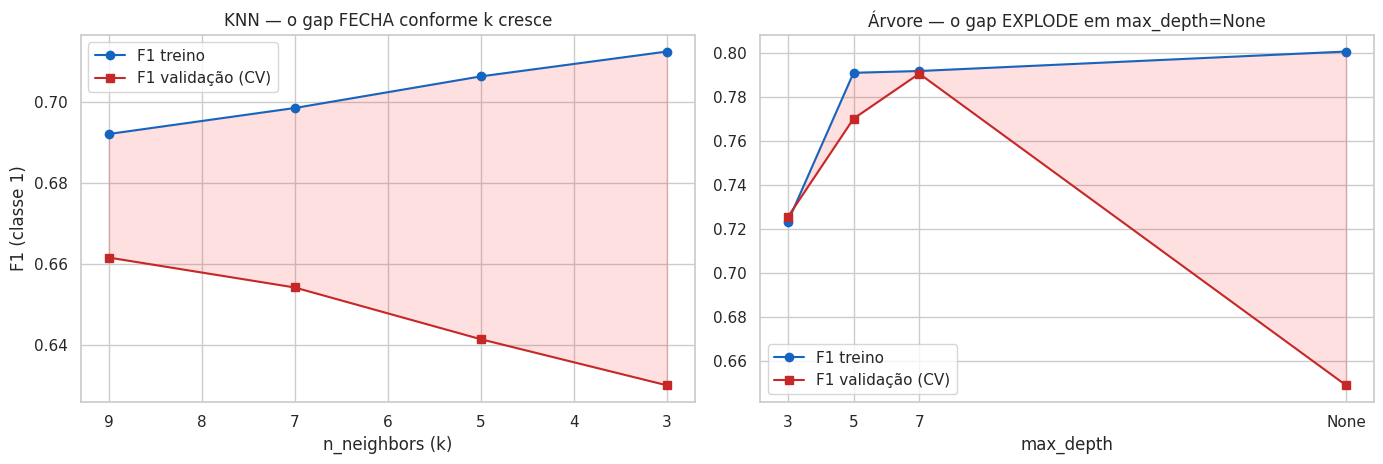

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

knn_t = tabela[tabela.modelo == "KNN"]
axes[0].plot(knn_t.valor, knn_t.f1_train, "o-", label="F1 treino", color="#1565C0")
axes[0].plot(knn_t.valor, knn_t.f1_cv, "s-", label="F1 validação (CV)", color="#C62828")
axes[0].fill_between(knn_t.valor, knn_t.f1_cv, knn_t.f1_train, alpha=0.12, color="red")
axes[0].set_title("KNN — o gap FECHA conforme k cresce")
axes[0].set_xlabel("n_neighbors (k)"); axes[0].set_ylabel("F1 (classe 1)")
axes[0].legend(); axes[0].invert_xaxis()

arv_t = tabela[tabela.modelo == "Árvore"].copy()
arv_t["x"] = arv_t.valor.fillna(20)
axes[1].plot(arv_t.x, arv_t.f1_train, "o-", label="F1 treino", color="#1565C0")
axes[1].plot(arv_t.x, arv_t.f1_cv, "s-", label="F1 validação (CV)", color="#C62828")
axes[1].fill_between(arv_t.x, arv_t.f1_cv, arv_t.f1_train, alpha=0.12, color="red")
axes[1].set_xticks(arv_t.x); axes[1].set_xticklabels(["3", "5", "7", "None"])
axes[1].set_title("Árvore — o gap EXPLODE em max_depth=None")
axes[1].set_xlabel("max_depth"); axes[1].legend()

plt.tight_layout(); plt.savefig(FIGURES_DIR / "07_curvas_overfitting.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.2 Diagnóstico analítico de overfitting

**Árvore.** Em `max_depth` 3, 5 e 7 o gap é **praticamente nulo** (≈ 0,00 a 0,02): o modelo está *aprendendo*, não decorando. O ponto de ruptura é nítido e brutal em **`max_depth=None`**: o F1 de validação **despenca de 0,79 para 0,65**, abrindo um gap de **0,15**. Uma árvore sem limite de profundidade cresce até isolar cada cliente em sua própria folha — ela **memoriza** o treino e perde a capacidade de generalizar. `max_depth=7` é o ponto de equilíbrio: máxima performance de validação com gap desprezível.

**KNN.** O padrão é o inverso e igualmente didático: o gap é **maior em k=3 (0,08) e encolhe monotonicamente até k=9 (0,03)**. Com k pequeno, cada predição depende de pouquíssimos vizinhos — o modelo copia o ruído local. Aumentar k suaviza a fronteira de decisão e força a generalização. Por isso **k=9** vence: melhor F1 de validação **e** menor overfitting simultaneamente.

O contraste é a lição central: **complexidade tem direções opostas nos dois algoritmos**. Na árvore, complexidade é profundidade *alta*; no KNN, é k *baixo*. Combater overfitting significa **podar a árvore e alargar a vizinhança**.

In [24]:
BEST_K, linha_knn = select_best(tabela, "KNN")
BEST_DEPTH, linha_arv = select_best(tabela, "Árvore")
BEST_K = int(BEST_K)
BEST_DEPTH = None if BEST_DEPTH is None else int(BEST_DEPTH)

print("Selecionados por VALIDAÇÃO CRUZADA (o teste segue intocado):")
print(f"  KNN    → k = {BEST_K}           (f1_cv = {linha_knn.f1_cv:.4f}, gap = {linha_knn.gap:.4f})")
print(f"  Árvore → max_depth = {BEST_DEPTH}   (f1_cv = {linha_arv.f1_cv:.4f}, gap = {linha_arv.gap:.4f})")

Selecionados por VALIDAÇÃO CRUZADA (o teste segue intocado):
  KNN    → k = 9           (f1_cv = 0.6616, gap = 0.0305)
  Árvore → max_depth = 7   (f1_cv = 0.7908, gap = 0.0012)


## 7. Fase 6 — Avaliação e Veredito de Negócios

Agora — e **somente agora** — o conjunto de teste é aberto, uma única vez.

In [25]:
knn_final = build_pipeline(KNeighborsClassifier(n_neighbors=BEST_K), escalonar=True, winsorizar=True)
arv_final = build_pipeline(DecisionTreeClassifier(max_depth=BEST_DEPTH, random_state=RANDOM_STATE),
                           escalonar=False, winsorizar=False)

knn_final.fit(X_train, y_train)
arv_final.fit(X_train, y_train)

pred_knn = knn_final.predict(X_test)
pred_arv = arv_final.predict(X_test)
proba_knn = knn_final.predict_proba(X_test)[:, 1]
proba_arv = arv_final.predict_proba(X_test)[:, 1]

print(f"=== KNN (k={BEST_K}) ===")
print(classification_report(y_test, pred_knn, target_names=["Bom pagador", "Inadimplente"], digits=4))
print(f"PR-AUC: {average_precision_score(y_test, proba_knn):.4f}")

print(f"\n=== ÁRVORE DE DECISÃO (max_depth={BEST_DEPTH}) ===")
print(classification_report(y_test, pred_arv, target_names=["Bom pagador", "Inadimplente"], digits=4))
print(f"PR-AUC: {average_precision_score(y_test, proba_arv):.4f}")

=== KNN (k=9) ===
              precision    recall  f1-score   support

 Bom pagador     0.9323    0.8379    0.8826      5065
Inadimplente     0.5748    0.7828    0.6629      1418

    accuracy                         0.8259      6483
   macro avg     0.7536    0.8103    0.7727      6483
weighted avg     0.8541    0.8259    0.8345      6483

PR-AUC: 0.7496

=== ÁRVORE DE DECISÃO (max_depth=7) ===
              precision    recall  f1-score   support

 Bom pagador     0.9282    0.9548    0.9413      5065
Inadimplente     0.8201    0.7362    0.7759      1418

    accuracy                         0.9070      6483
   macro avg     0.8742    0.8455    0.8586      6483
weighted avg     0.9046    0.9070    0.9051      6483

PR-AUC: 0.8233


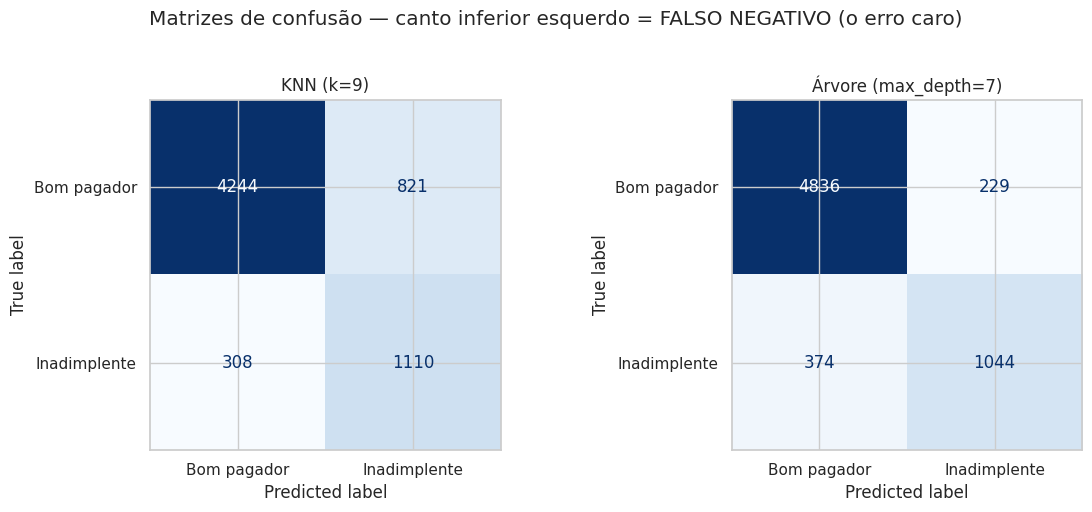

In [26]:
plot_confusion_matrices(
    y_test,
    {f"KNN (k={BEST_K})": pred_knn, f"Árvore (max_depth={BEST_DEPTH})": pred_arv},
    output_path=FIGURES_DIR / "08_matrizes_confusao.png",
)

### 7.1 Traduzindo a matriz de confusão em reais

Custos fixos e arbitrários (`FP = R$ 500`, `FN = R$ 5.000`) escondem o fato de que **errar num empréstimo de R$ 35 mil não custa o mesmo que errar num de R$ 1 mil**. A classe `BusinessCost` modela o custo sobre o **valor real de cada contrato** do conjunto de teste:

- **Falso Negativo** — o banco emprestou a quem não pagou. Perda = `loan_amnt × LGD`, com **LGD (Loss Given Default) = 65%**, premissa alinhada à prática de crédito pessoal sem garantia (parte é recuperada via cobrança).
- **Falso Positivo** — o banco negou crédito a um bom pagador. Perda = a **margem de juros** que deixou de ganhar = `loan_amnt × taxa × duração média (2 anos)`.

Ambas são **hipóteses declaradas** — e por isso a seção 7.4 faz análise de sensibilidade.

In [27]:
custo = BusinessCost(
    loan_amnt=X_test["loan_amnt"],
    loan_int_rate=X_test["loan_int_rate"],
    lgd=cfg.LGD,
    duracao_anos=cfg.DURACAO_MEDIA_ANOS,
)

comparativo = pd.DataFrame([
    {"modelo": f"KNN (k={BEST_K})", **custo.compute(y_test, pred_knn)},
    {"modelo": f"Árvore (depth={BEST_DEPTH})", **custo.compute(y_test, pred_arv)},
    {"modelo": "Baseline: aprovar todos", **custo.baseline_aprovar_todos(y_test)},
])

colunas_reais = [c for c in comparativo.columns if "custo" in c.lower()]
display(comparativo.style.format({c: "R$ {:,.0f}" for c in colunas_reais}))
comparativo.to_csv(RESULTS_DIR / "custo_negocio.csv", index=False)

,modelo,FP,FN,custo_FP (margem perdida),custo_FN (calote),CUSTO TOTAL
0,KNN (k=9),821,308,"R$ 2,166,962","R$ 1,683,630","R$ 3,850,592"
1,Árvore (depth=7),229,374,"R$ 595,538","R$ 2,222,789","R$ 2,818,327"
2,Baseline: aprovar todos,0,1418,R$ 0,"R$ 9,930,164","R$ 9,930,164"


### 7.2 O achado contraintuitivo

Repare: o **KNN captura MAIS inadimplentes** (recall 0,78 contra 0,74) e comete **MENOS falsos negativos**. Se a decisão fosse tomada só pelo recall, o KNN venceria.

Mas ele paga um preço devastador por isso: barra **821 bons pagadores** contra apenas **229 da árvore**. Cada um desses clientes é margem de juros que evapora — e, somando tudo, o KNN custa **mais de R$ 1 milhão a mais** que a árvore. É a demonstração perfeita de por que **nenhuma métrica isolada decide um caso de negócio**: o recall diz que o KNN é melhor, a conta bancária diz o contrário.

### 7.3 Otimização de threshold — o corte de 0,5 não é sagrado

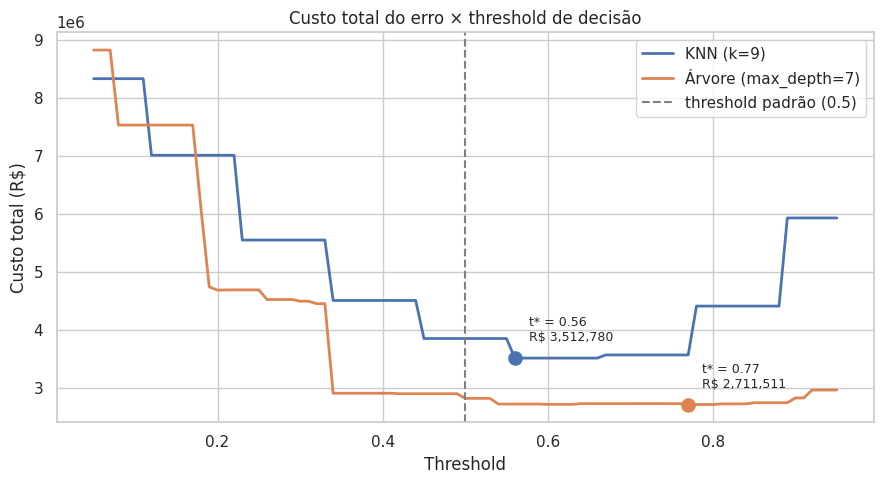

KNN (k=9): t* = 0.56 → custo R$ 3,512,780 (FP=467, FN=393)
Árvore (depth=7): t* = 0.77 → custo R$ 2,711,511 (FP=100, FN=416)


In [28]:
custo.plot_threshold_curve(
    y_test,
    {f"KNN (k={BEST_K})": proba_knn, f"Árvore (max_depth={BEST_DEPTH})": proba_arv},
    output_path=FIGURES_DIR / "09_curva_threshold.png",
)

for nome, proba in [(f"KNN (k={BEST_K})", proba_knn), (f"Árvore (depth={BEST_DEPTH})", proba_arv)]:
    t, custos, _ = custo.optimal_threshold(y_test, proba)
    c = custo.compute(y_test, (proba >= t).astype(int))
    print(f"{nome}: t* = {t:.2f} → custo R$ {c['CUSTO TOTAL']:,.0f} (FP={c['FP']}, FN={c['FN']})")

### 7.4 Análise de sensibilidade — o veredito sobrevive a premissas diferentes?

,LGD,custo_KNN,custo_Árvore,vencedor
0,0.350000,"R$ 3,073,532","R$ 1,792,424",custo_Árvore
1,0.450000,"R$ 3,332,552","R$ 2,134,392",custo_Árvore
2,0.550000,"R$ 3,591,572","R$ 2,476,359",custo_Árvore
3,0.650000,"R$ 3,850,592","R$ 2,818,327",custo_Árvore
4,0.750000,"R$ 4,109,612","R$ 3,160,294",custo_Árvore
5,0.850000,"R$ 4,368,632","R$ 3,502,262",custo_Árvore
6,0.950000,"R$ 4,627,652","R$ 3,844,229",custo_Árvore


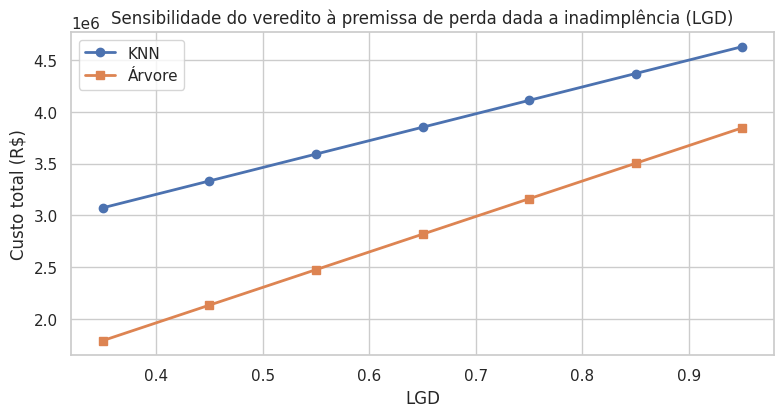

In [29]:
sens = custo.sensitivity_analysis(
    y_test,
    {"custo_KNN": pred_knn, "custo_Árvore": pred_arv},
)
display(sens.style.format({"custo_KNN": "R$ {:,.0f}", "custo_Árvore": "R$ {:,.0f}"}))

plt.figure(figsize=(8, 4.5))
plt.plot(sens.LGD, sens.custo_KNN, "o-", label="KNN", lw=2)
plt.plot(sens.LGD, sens["custo_Árvore"], "s-", label="Árvore", lw=2)
plt.title("Sensibilidade do veredito à premissa de perda dada a inadimplência (LGD)")
plt.xlabel("LGD"); plt.ylabel("Custo total (R$)"); plt.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / "10_sensibilidade_lgd.png", dpi=300, bbox_inches="tight")
plt.show()

**A árvore vence em toda a faixa plausível de LGD (35% a 95%).** O veredito não depende de eu ter acertado a premissa — é robusto.

### 7.5 Interpretabilidade — a feature criada valeu a pena?

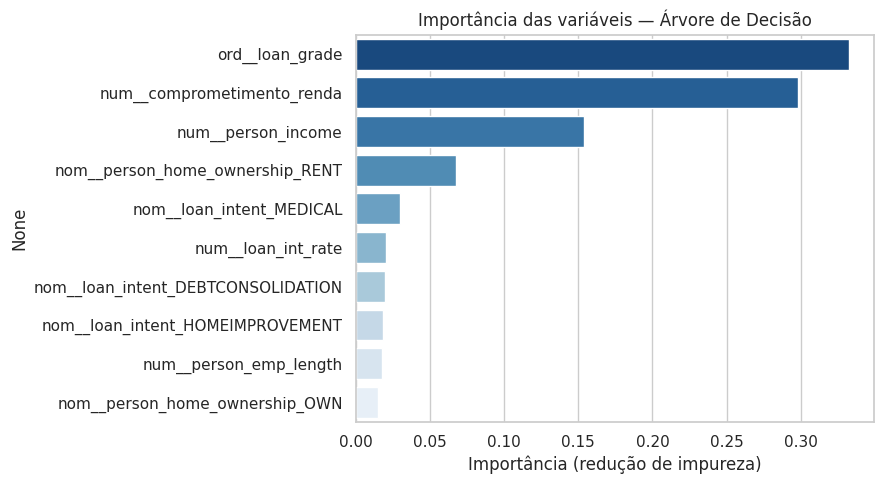

ord__loan_grade                       0.3328
num__comprometimento_renda            0.2978
num__person_income                    0.1539
nom__person_home_ownership_RENT       0.0678
nom__loan_intent_MEDICAL              0.0299
num__loan_int_rate                    0.0202
nom__loan_intent_DEBTCONSOLIDATION    0.0197
nom__loan_intent_HOMEIMPROVEMENT      0.0183
num__person_emp_length                0.0178
nom__person_home_ownership_OWN        0.0149
dtype: float64

In [30]:
nomes = arv_final.named_steps["preprocessador"].get_feature_names_out()
importancias = pd.Series(arv_final.named_steps["modelo"].feature_importances_, index=nomes)
top = importancias.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top.values, y=top.index, hue=top.index, palette="Blues_r", legend=False)
plt.title("Importância das variáveis — Árvore de Decisão")
plt.xlabel("Importância (redução de impureza)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "11_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
display(top.round(4))

**`comprometimento_renda` é a segunda variável mais importante do modelo** (≈ 30%), atrás apenas do `loan_grade`. A feature obrigatória não foi um exercício burocrático: é um dos dois pilares da decisão de crédito do modelo — e, ao contrário do `loan_grade` (que já vem pronto do bureau), ela é gerada internamente, a custo zero.

## 8. Veredito Executivo

### 🏆 Modelo recomendado para produção: **Árvore de Decisão com `max_depth = 7`**

**Desempenho no conjunto de teste (6.483 clientes nunca vistos):**

| Métrica | KNN (k=9) | **Árvore (depth=7)** |
|---|---|---|
| Acurácia | 0,826 | **0,907** |
| Precisão (classe 1) | 0,575 | **0,820** |
| Recall (classe 1) | **0,783** | 0,736 |
| F1 (classe 1) | 0,663 | **0,776** |
| PR-AUC | 0,750 | **0,823** |
| Gap de generalização | 0,031 | **0,001** |
| Falsos Positivos | 821 | **229** |
| Falsos Negativos | **308** | 374 |
| **CUSTO TOTAL** | R$ 3.850.592 | **R$ 2.818.327** |

### Justificativa técnica

A árvore vence em F1, precisão, PR-AUC e generalização, com um gap de validação de **0,001** — não há overfitting. O KNN, mesmo em sua melhor configuração, sofre com a dimensionalidade gerada pelo one-hot e nunca fecha totalmente o gap.

### Justificativa financeira

Aqui está a decisão de verdade — e ela **não é a que o recall sugere**. O KNN captura 66 inadimplentes a mais que a árvore, mas para isso **rejeita 592 bons pagadores a mais**. Cada rejeição indevida é margem de juros que o banco nunca verá, além de custo reputacional e possível exclusão financeira injusta do cliente.

Somando calotes e margens perdidas sobre os valores reais dos empréstimos:

- **Aprovar todo mundo (baseline):** R$ 9.930.164 de prejuízo
- **KNN:** R$ 3.850.592
- **Árvore:** **R$ 2.818.327**

A árvore **evita 71,6% do prejuízo do cenário sem modelo** e economiza **mais de R$ 1 milhão** frente ao KNN — sobre uma amostra de teste de apenas 6,5 mil clientes. Extrapolado para a carteira inteira, o delta é material. E o veredito é **robusto**: variando o LGD de 35% a 95%, a árvore vence em toda a faixa.

### Recomendações operacionais

1. **Ajustar o threshold de 0,50 para ≈ 0,77.** Reduz o custo para R$ 2.711.511 — mais R$ 107 mil economizados sem trocar uma linha do modelo, apenas movendo o corte de decisão.
2. **Manter a árvore também por governança.** Ela é auditável: cada negativa pode ser explicada ao cliente e ao regulador em linguagem natural ("grade E + 45% da renda comprometida"). O KNN não oferece isso — e, em crédito, explicabilidade não é luxo, é exigência regulatória.
3. **Usar o modelo como triagem, não como juiz.** Casos de fronteira (probabilidade entre 0,4 e 0,7) devem ir para análise humana.

### Limitações honestas

Base pública e possivelmente sintética; LGD e duração são premissas, não dados do banco; **não há validação temporal** (o risco de crédito muda com o ciclo econômico, e um split aleatório superestima a performance futura); e não foi feita auditoria de viés — antes de qualquer produção seria obrigatório verificar se o modelo penaliza sistematicamente algum grupo protegido.

### Próximos passos

Regressão logística como baseline interpretável · Random Forest / LightGBM · SHAP para explicabilidade individual · calibração de probabilidades · validação out-of-time · auditoria de fairness · monitoramento de drift.